In [ ]:
import os
from pathlib import Path
artifacts_dir = Path("/kaggle/working/artifacts")
for f in sorted(artifacts_dir.iterdir()):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"{f.name:<40} {size_mb:.1f} MB")

In [ ]:
import shutil
for name in ["cleaned_train", "cleaned_test", "gradcam_audit"]:
    p = artifacts_dir / name
    if p.exists():
        total = sum(f.stat().st_size for f in p.rglob("*") if f.is_file())
        print(f"{name}: {total / (1024*1024):.1f} MB, {len(list(p.rglob('*')))} files")
    else:
        print(f"{name}: doesn't exist")


# Explainable & Uncertainty-Aware Deep Learning for Multi-Class Skin Lesion Classification
### ISIC 2019 · EfficientNet-B3 · Grad-CAM · MC Dropout · Calibration · Human-in-the-Loop
### Configured for Kaggle (`ISIC 2019 Dataset Full`)

This notebook implements the **entire project workflow end-to-end**, in the order it needs to run:

1. Data collection / dataset location & sanity checks
2. Data cleaning (duplicates, corrupt files, unknown-class handling, leakage checks)
3. Dermoscopy-specific image preprocessing (hair removal, border/vignette crop, color constancy)
4. Stratified train/val split + class-imbalance handling (class weights + weighted sampler)
5. Augmentation pipeline (Albumentations)
6. EfficientNet-B3 model (timm) with MC-Dropout-ready head
7. Two-phase transfer learning training loop (head-only → fine-tune) with literature-grounded hyperparameters
8. Multi-class prediction generation
9. Grad-CAM explainability
10. Monte Carlo Dropout uncertainty estimation
11. Confidence calibration (reliability diagrams + ECE)
12. Human-in-the-Loop decision framework (confidence threshold routing)
13. Decision logging / audit trail
14. Full model + HITL evaluation
15. **Export everything needed to build the Streamlit app later** (weights, config, thresholds, label maps, transform config)

> **Data layout (Kaggle "ISIC 2019 Dataset Full"):** this notebook is wired to the exact structure
> that dataset produces once added as a Kaggle input:
> ```
> /kaggle/input/isic-2019-dataset-full/isic-2019-dataset-full/
>   train/                               <- training .jpg images (possibly nested subfolders — handled below)
>   test/                                <- official test .jpg images
>   ISIC_2019_Training_GroundTruth.csv
>   ISIC_2019_Training_Metadata.csv
>   ISIC_2019_Test_GroundTruth.csv
>   ISIC_2019_Test_Metadata.csv
> ```
> Because this dataset ships **labeled** train *and* test ground truth, Section 5 uses the `test/`
> folder as the real held-out evaluation set (rather than carving a test split out of the training
> pool ourselves) and only splits the `train/` pool into train/val. If you swap in a different
> ISIC 2019 upload that doesn't include test labels, the notebook automatically falls back to
> carving its own stratified test split from the training pool — no manual changes needed.
>
> Running locally instead of on Kaggle? Just edit `CONFIG["data_root"]` in Section 1 to point at
> wherever you extracted the data — everything else is derived from that one path.


## 0. Environment setup

Installs (skip if already installed) and imports used throughout the notebook.

In [1]:

import sys, subprocess, importlib

# On Kaggle: Settings -> Internet -> On (required for pip installs) and Accelerator -> GPU.
# `timm`, `albumentations`, `torch`, `opencv` ship preinstalled on Kaggle's GPU image; `grad-cam`
# usually does not, so we install just that (fast, no-op if already present).
for pkg, import_name in [("grad-cam", "pytorch_grad_cam")]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

# If running fresh locally (e.g. new venv, not Kaggle), uncomment the full install instead:
# !pip install -q timm==1.0.9 albumentations==1.4.15 grad-cam==1.5.4 torchmetrics==1.4.1 scikit-learn pandas numpy matplotlib seaborn tqdm

import os, json, random, math, time, copy, hashlib, warnings, re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import cv2
cv2.setNumThreads(0)   # CRITICAL: OpenCV's internal threading corrupts image reads when combined
                        # with PyTorch multiprocessing DataLoader workers (num_workers > 0). This
                        # silently produces garbage/near-uniform predictions rather than crashing --
                        # it must be set before ANY DataLoader with num_workers>0 is created, so it
                        # lives here, in the very first code cell, before anything else runs.
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## 1. Project configuration

Everything the pipeline needs (paths, hyperparameters, class list) lives in one `CONFIG` dict.
This is **exactly** what gets dumped to `config.json` at the end so the future Streamlit app
can load the model with identical preprocessing/inference settings — no re-guessing constants.

### Hyperparameter choices (grounded in ISIC/dermoscopy transfer-learning literature)
- **Backbone:** EfficientNet-B3 (300×300 — B3's native training resolution, per the original
  EfficientNet compound-scaling paper). Literature comparing EfficientNet variants on skin lesion
  classification (HAM10000/ISIC) finds the B4–B5 range peaks on raw top-1 accuracy but B0–B3 trail
  by only a few points while being far cheaper to train; B3 is a deliberate middle ground between
  B0's spec-default and the heavier B4+ variants — meaningfully more capacity than B0 without the
  training cost/overfitting risk of B4+ on a ~25k-image dataset.
- **Two-phase training:** (1) freeze backbone, train head only, `lr=1e-3`; (2) unfreeze last blocks,
  fine-tune whole net at `lr=1e-4` (head) / `1e-5` (backbone) — discriminative LR is standard practice
  for adapting ImageNet features to dermoscopic textures without destroying pretrained filters.
- **Optimizer:** AdamW, `weight_decay=1e-4` for head / `5e-4`-ish decoupled regularization — published
  ISIC ablations show naively large LR + weak decay destabilizes minority-class performance
  (small/rare classes like DF, VASC swing wildly), so we deliberately keep LR modest and use
  a cosine schedule with warmup rather than one-shot high LR.
- **Loss:** class-weighted cross-entropy (inverse-frequency weights, square-root dampened) +
  label smoothing 0.1. Weighted CE is combined with a `WeightedRandomSampler` (belt-and-braces
  imbalance handling per the project spec) rather than naive oversampling alone, since oversampling-only
  tends to overfit the ~200-image DF/VASC classes when repeated many times per epoch.
- **Batch size:** 24 (300×300 images, EfficientNet-B3) — sized for a single Kaggle GPU (T4/P100,
  ~16GB) with AMP; larger than this risks OOM on B3 at 300×300, smaller under-utilizes the GPU.
- **Epochs:** up to 30 per phase with early stopping on validation macro-F1 (patience 6).
- **Augmentation:** rotation/flips/zoom/brightness (per spec) implemented via Albumentations,
  plus dermoscopy-appropriate touches: hue/saturation jitter (skin tone/lighting variance),
  CoarseDropout (simulates hair/occlusion), and no aggressive geometric warps that would distort
  lesion borders (which are diagnostically meaningful).
- **MC Dropout:** dropout in the classifier head kept active at inference, 30 stochastic passes
  (project spec's 30–50 range; 30 chosen for latency in a future Streamlit demo).

### Kaggle-specific notes
- `num_workers=2` — Kaggle notebook CPUs are limited; more workers than available cores just adds
  overhead.
- Image cleaning (Section 4) defaults to **on-the-fly** rather than caching a second full copy of
  the dataset to disk (`RUN_CACHING = False`), because `/kaggle/working` output is capped around
  20GB and a full cleaned-image cache would consume most of that budget. Flip it to `True` only if
  you've confirmed you have headroom.
- Remember to **turn on GPU** in the notebook's settings panel (Settings → Accelerator → GPU
  T4 x2 or P100) before running — training EfficientNet-B3 on CPU is impractically slow.


In [2]:

CONFIG = {
    # ---- paths (Kaggle "ISIC 2019 Dataset Full" layout — edit data_root if running elsewhere) ----
    "data_root": "/kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full",
    "train_images_dir": "train",                       # searched recursively -> nesting doesn't matter
    "test_images_dir": "test",
    "train_ground_truth_csv": "ISIC_2019_Training_GroundTruth.csv",
    "train_metadata_csv": "ISIC_2019_Training_Metadata.csv",
    "test_ground_truth_csv": "ISIC_2019_Test_GroundTruth.csv",   # if absent, notebook falls back to
    "test_metadata_csv": "ISIC_2019_Test_Metadata.csv",          # carving a test split from train
    "output_dir": "/kaggle/working/artifacts",

    # ---- classes ----
    "class_names": ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"],  # UNK excluded (see cleaning step)
    "melanoma_class": "MEL",

    # ---- image ----
    "image_size": 300,            # EfficientNet-B3 native training resolution
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],

    # ---- split (only used in the no-official-test-labels fallback path, see Section 5) ----
    "test_size": 0.15,
    "val_size": 0.15,   # fraction of the training pool held out for validation
    "split_seed": SEED,

    # ---- dataloader ----
    "batch_size": 24,     # sized for EfficientNet-B3 @ 300x300 on a single Kaggle GPU (T4/P100) with AMP
    "num_workers": 2,     # Kaggle notebook CPU budget is limited

    # ---- model ----
    "backbone": "efficientnet_b3",
    "dropout_p": 0.45,            # was 0.3 -- raised for regularization (overfitting observed:
                                   # train F1 ~0.82 vs val F1 ~0.54 in initial runs)
    "pretrained": True,

    # ---- training phase 1 (head only) ----
    "phase1_epochs": 10,
    "phase1_lr": 5e-4,             # was 1e-3 -- lowered; original caused val F1 to oscillate/drift
                                    # instead of climbing steadily during head-only warmup
    "phase1_weight_decay": 1e-4,

    # ---- training phase 2 (fine-tune, unfreeze last N blocks) ----
    "phase2_epochs": 30,
    "phase2_lr_head": 1e-4,
    "phase2_lr_backbone": 5e-6,    # was 1e-5 -- halved, less freedom for backbone to overfit
    "phase2_weight_decay": 3e-4,   # was 1e-4 -- stronger regularization
    "unfreeze_last_n_blocks": 2,   # was 3 -- less of the backbone unfrozen, less capacity to memorize

    # ---- optimization ----
    "label_smoothing": 0.1,
    "warmup_epochs": 3,            # was 2 -- smoother ramp-up, pairs with the lower phase1_lr
    "early_stopping_patience": 6,
    "grad_clip_norm": 1.0,
    "use_amp": True,

    # ---- class imbalance ----
    "class_weight_power": 0.3,     # was 0.5 -- gentler weighting; 0.5 was over-repeating the
                                    # ~200-image DF/VASC classes via the sampler, encouraging
                                    # memorization rather than generalization
    "use_weighted_sampler": True,

    # ---- MC Dropout ----
    "mc_dropout_passes": 30,

    # ---- calibration / HITL ----
    "n_calibration_bins": 10,
    "confidence_threshold": 0.70,   # predictions below this are routed to human review
                                     # (re-tuned empirically in Section 11 using validation data)
    "melanoma_review_floor": 0.90,  # ANY Melanoma-suspicious case below this confidence is
                                     # force-reviewed regardless of the general threshold,
                                     # reflecting the clinical priority on melanoma recall

    # ---- ensembling / TTA (Section 19 -- optional accuracy boost) ----
    "ensemble_members": [
        # Each entry trains an additional, architecturally-different model and averages its
        # predictions with the primary EfficientNet-B3. Kept smaller/faster than B3 so the
        # combined extra training time stays reasonable on a single Kaggle GPU.
        {"backbone": "tf_efficientnet_b0", "image_size": 224, "batch_size": 48,
         "phase1_epochs": 6, "phase2_epochs": 15, "unfreeze_last_n_blocks": 2},
        {"backbone": "resnet50", "image_size": 224, "batch_size": 48,
         "phase1_epochs": 6, "phase2_epochs": 15, "unfreeze_last_n_blocks": 2},
    ],
    "tta_enabled": True,   # horizontal + vertical flip averaging at inference, cheap accuracy boost

    "seed": SEED,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
DATA_ROOT = Path(CONFIG["data_root"])
TRAIN_IMG_DIR = DATA_ROOT / CONFIG["train_images_dir"]
TEST_IMG_DIR = DATA_ROOT / CONFIG["test_images_dir"]
TRAIN_GT_CSV = DATA_ROOT / CONFIG["train_ground_truth_csv"]
TRAIN_META_CSV = DATA_ROOT / CONFIG["train_metadata_csv"]
TEST_GT_CSV = DATA_ROOT / CONFIG["test_ground_truth_csv"]
TEST_META_CSV = DATA_ROOT / CONFIG["test_metadata_csv"]
class_cols = CONFIG["class_names"]

print(json.dumps(CONFIG, indent=2))


{
  "data_root": "/kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full",
  "train_images_dir": "train",
  "test_images_dir": "test",
  "train_ground_truth_csv": "ISIC_2019_Training_GroundTruth.csv",
  "train_metadata_csv": "ISIC_2019_Training_Metadata.csv",
  "test_ground_truth_csv": "ISIC_2019_Test_GroundTruth.csv",
  "test_metadata_csv": "ISIC_2019_Test_Metadata.csv",
  "output_dir": "/kaggle/working/artifacts",
  "class_names": [
    "MEL",
    "NV",
    "BCC",
    "AK",
    "BKL",
    "DF",
    "VASC",
    "SCC"
  ],
  "melanoma_class": "MEL",
  "image_size": 300,
  "imagenet_mean": [
    0.485,
    0.456,
    0.406
  ],
  "imagenet_std": [
    0.229,
    0.224,
    0.225
  ],
  "test_size": 0.15,
  "val_size": 0.15,
  "split_seed": 42,
  "batch_size": 24,
  "num_workers": 2,
  "backbone": "efficientnet_b3",
  "dropout_p": 0.45,
  "pretrained": true,
  "phase1_epochs": 10,
  "phase1_lr": 0.0005,
  "phase1_weight_decay": 0.0001,
  "phase2_epochs": 30,
 

In [3]:
CONFIG["ensemble_members"][0]["batch_size"] = 24   # was 48
CONFIG["ensemble_members"][1]["batch_size"] = 24   # was 48
CONFIG["num_workers"] = 1                           # was 2
print("Overridden ensemble batch sizes and num_workers for this run.")

Overridden ensemble batch sizes and num_workers for this run.


## 2. Data collection sanity checks

Confirms the dataset is where `CONFIG` expects it before doing anything else. If running on
Kaggle, this means the `ISIC 2019 Dataset Full` input has been added via **+ Add Input** in the
notebook sidebar (see the intro cell for the exact expected layout). If you haven't downloaded the
data yet, the original release is at https://challenge.isic-archive.com/data/#2019.

In [4]:

assert DATA_ROOT.exists(), (
    f"DATA_ROOT not found: {DATA_ROOT}. On Kaggle: click '+ Add Input' in the sidebar and attach "
    f"the ISIC 2019 dataset, then confirm the path with `!ls /kaggle/input`. Locally: set "
    f"CONFIG['data_root'] to your extracted ISIC 2019 folder."
)
assert TRAIN_GT_CSV.exists(), f"Training ground truth CSV not found at {TRAIN_GT_CSV}."
assert TRAIN_IMG_DIR.exists(), f"Training image folder not found at {TRAIN_IMG_DIR}."

raw_train_df = pd.read_csv(TRAIN_GT_CSV)
print("Training ground truth shape:", raw_train_df.shape)

HAS_OFFICIAL_TEST = TEST_GT_CSV.exists() and TEST_IMG_DIR.exists()
if HAS_OFFICIAL_TEST:
    raw_test_df = pd.read_csv(TEST_GT_CSV)
    print("Official labeled test set found:", raw_test_df.shape)
else:
    raw_test_df = None
    print("No labeled official test set found at the configured path — "
          "Section 5 will carve a held-out test split from the training pool instead.")

raw_train_df.head()


Training ground truth shape: (25331, 10)
Official labeled test set found: (8238, 12)


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Data Cleaning

Standard ISIC 2019 cleaning steps applied here:

1. **Unknown class (`UNK`) removal** — the official release includes an `UNK` column for images
   the challenge didn't disclose a firm label for (used only for the withheld test set). We drop
   any row where `UNK == 1` since we can't supervise on it, keeping the 8 disclosed diagnostic
   categories the project spec lists.
2. **Single-label sanity check** — the ground truth is one-hot; verify each row sums to exactly 1
   across the 8 disclosed classes (post-UNK-drop) and drop any malformed rows.
3. **Missing / corrupt image check** — verify every referenced image file exists and opens with
   OpenCV; drop any row whose image is missing or unreadable.
4. **Duplicate detection** — ISIC is known to contain some near-duplicate images (same lesion,
   multiple captures). We hash-dedupe exact-duplicate files and additionally use `lesion_id`
   from the metadata (if present) to make sure the *same lesion* never appears in both train and
   test (patient/lesion-level leakage is a well-documented ISIC pitfall).
5. **Class distribution audit** — visualize the (expected, heavy) imbalance so the imbalance
   handling in Section 5 is sanity-checked against actual counts.

In [5]:

# Kaggle re-uploads sometimes nest images one level deeper than expected (e.g. train/train/*.jpg
# instead of train/*.jpg). Rather than guess, we build a filename -> path index with one recursive
# scan per pool, then look every image up in that index. This is robust to any nesting depth.
ISIC_ID_PATTERN = re.compile(r"(ISIC_\d+)")

def build_image_index(base_dir):
    '''Recursively indexes image files, keyed by the canonical ISIC image id (e.g. "ISIC_0012345")
    so the ground-truth CSV's "image" column always resolves. Handles two known real-world quirks
    in ISIC re-uploads: (1) non-image files (attribution.txt, LICENSE, .json sidecars) sitting in
    the same folders -- these are excluded purely by file extension, regardless of alphabetical
    order; (2) renamed duplicates like "ISIC_0014233_downsampled.jpg" -- these are only used as a
    fallback when no exact "ISIC_0014233.jpg" exists, so a clean original always wins if present.'''
    all_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG"):
        all_paths.extend(Path(base_dir).rglob(ext))

    index, fallback = {}, {}
    for p in all_paths:
        stem = p.stem
        if ISIC_ID_PATTERN.fullmatch(stem):
            index[stem] = p                                    # exact canonical match -> always wins
        else:
            m = ISIC_ID_PATTERN.match(stem)
            if m:
                fallback.setdefault(m.group(1), p)              # e.g. "..._downsampled" -> fills gaps only
    for base_id, p in fallback.items():
        index.setdefault(base_id, p)

    # Transparency check: show what else is sitting in the folder tree and confirm none of it
    # was accidentally treated as an image.
    all_files = [p for p in Path(base_dir).rglob("*") if p.is_file()]
    non_image_files = [p for p in all_files if p.suffix.lower() not in (".jpg", ".jpeg")]
    if non_image_files:
        print(f"  (Found {len(non_image_files)} non-image file(s) in {base_dir} -- "
              f"e.g. {[p.name for p in non_image_files[:3]]} -- correctly excluded from the index.)")
    n_exact = sum(1 for p in all_paths if ISIC_ID_PATTERN.fullmatch(p.stem))
    n_fallback_used = len(index) - n_exact
    if n_fallback_used > 0:
        print(f"  (Matched {n_fallback_used} image(s) via a renamed/suffixed filename, "
              f"e.g. '..._downsampled.jpg', since no exact-named file existed for that id.)")
    return index

print("Indexing training images (one-time recursive scan)...")
train_image_index = build_image_index(TRAIN_IMG_DIR)
print(f"Found {len(train_image_index):,} image files under {TRAIN_IMG_DIR}")

if HAS_OFFICIAL_TEST:
    print("Indexing test images...")
    test_image_index = build_image_index(TEST_IMG_DIR)
    print(f"Found {len(test_image_index):,} image files under {TEST_IMG_DIR}")

def clean_dataframe(raw_df, image_index, meta_csv_path, class_cols, pool_name):
    '''Runs the full cleaning pipeline (steps 1-4 below) on one labeled image pool.'''
    d = raw_df.copy()

    # 1) Drop UNK rows
    if "UNK" in d.columns:
        n_before = len(d)
        d = d[d["UNK"] != 1].drop(columns=["UNK"])
        print(f"[{pool_name}] Dropped {n_before - len(d)} rows with UNK==1. Remaining: {len(d)}")

    missing_cols = [c for c in class_cols if c not in d.columns]
    assert not missing_cols, f"[{pool_name}] Expected class columns missing from ground truth CSV: {missing_cols}"

    # 2) One-hot sanity check
    row_sums = d[class_cols].sum(axis=1)
    bad_rows = d[row_sums != 1]
    if len(bad_rows) > 0:
        print(f"[{pool_name}] Dropping {len(bad_rows)} malformed (non one-hot) rows.")
        d = d[row_sums == 1]

    d["label"] = d[class_cols].idxmax(axis=1)
    d["label_idx"] = d["label"].map({c: i for i, c in enumerate(class_cols)})

    # 3) Missing / corrupt image check (via the recursive index built above)
    d["img_path"] = d["image"].map(image_index)
    n_missing = d["img_path"].isna().sum()
    if n_missing:
        print(f"[{pool_name}] Dropping {n_missing} rows with no matching image file found on disk.")
    d = d[d["img_path"].notna()].copy()

    def is_readable(path):
        img = cv2.imread(str(path))
        return img is not None

    tqdm.pandas(desc=f"Verifying {pool_name} images")
    d["readable"] = d["img_path"].progress_apply(is_readable)
    n_bad = (~d["readable"]).sum()
    if n_bad:
        print(f"[{pool_name}] Dropping {n_bad} rows with corrupt/unreadable images.")
    d = d[d["readable"]].drop(columns=["readable"])

    # 4a) Exact-duplicate detection via file hash
    def file_hash(path, block_size=65536):
        h = hashlib.md5()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(block_size), b""):
                h.update(chunk)
        return h.hexdigest()

    print(f"[{pool_name}] Hashing files to find exact duplicates (can take a while on the full set)...")
    d["file_hash"] = d["img_path"].progress_apply(file_hash)
    dup_mask = d.duplicated(subset="file_hash", keep="first")
    print(f"[{pool_name}] Found {dup_mask.sum()} exact-duplicate images; dropping.")
    d = d[~dup_mask].drop(columns=["file_hash"])

    # 4b) Lesion-level id, if metadata is available (prevents lesion leakage across splits later)
    if meta_csv_path.exists():
        meta_df = pd.read_csv(meta_csv_path)
        if "lesion_id" in meta_df.columns:
            d = d.merge(meta_df[["image", "lesion_id"]], on="image", how="left")
            d["lesion_id"] = d["lesion_id"].fillna(d["image"])
        else:
            d["lesion_id"] = d["image"]
    else:
        d["lesion_id"] = d["image"]

    return d.reset_index(drop=True)

df = clean_dataframe(raw_train_df, train_image_index, TRAIN_META_CSV, class_cols, pool_name="train")
print(f"\nFinal cleaned TRAINING pool size: {len(df):,}")
df.to_csv(Path(CONFIG["output_dir"]) / "cleaned_train_labels.csv", index=False)

if HAS_OFFICIAL_TEST:
    test_df_official = clean_dataframe(raw_test_df, test_image_index, TEST_META_CSV, class_cols, pool_name="test")
    print(f"Final cleaned OFFICIAL TEST set size: {len(test_df_official):,}")
    test_df_official.to_csv(Path(CONFIG["output_dir"]) / "cleaned_test_labels.csv", index=False)
else:
    test_df_official = None

# Optional cross-pool leakage check: warn (don't silently fix) if any lesion_id appears in both pools
if test_df_official is not None:
    overlap = set(df["lesion_id"]) & set(test_df_official["lesion_id"])
    if overlap:
        print(f"\n⚠️  WARNING: {len(overlap)} lesion_id(s) appear in BOTH train and official test pools. "
              f"This is a known pitfall in some ISIC re-uploads; consider dropping overlapping "
              f"lesions from the training pool if strict leakage-free evaluation matters for your use case.")

df.head()


Indexing training images (one-time recursive scan)...
  (Found 2 non-image file(s) in /kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full/train -- e.g. ['LICENSE.txt', 'ATTRIBUTION.txt'] -- correctly excluded from the index.)
  (Matched 2074 image(s) via a renamed/suffixed filename, e.g. '..._downsampled.jpg', since no exact-named file existed for that id.)
Found 25,331 image files under /kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full/train
Indexing test images...
  (Found 2 non-image file(s) in /kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full/test -- e.g. ['LICENSE.txt', 'ATTRIBUTION.txt'] -- correctly excluded from the index.)
Found 8,238 image files under /kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full/test
[train] Dropped 0 rows with UNK==1. Remaining: 25331
[train] Dropping 2074 rows with no matching image file found on disk.


Verifying train images:   0%|          | 0/23257 [00:00<?, ?it/s]

[train] Hashing files to find exact duplicates (can take a while on the full set)...


Verifying train images:   0%|          | 0/23257 [00:00<?, ?it/s]

[train] Found 49 exact-duplicate images; dropping.

Final cleaned TRAINING pool size: 23,208
[test] Dropped 2047 rows with UNK==1. Remaining: 6191


Verifying test images:   0%|          | 0/6191 [00:00<?, ?it/s]

[test] Hashing files to find exact duplicates (can take a while on the full set)...


Verifying test images:   0%|          | 0/6191 [00:00<?, ?it/s]

[test] Found 0 exact-duplicate images; dropping.
Final cleaned OFFICIAL TEST set size: 6,191


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,label,label_idx,img_path,lesion_id
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,1,/kaggle/input/datasets/alifshahariar/isic-2019...,ISIC_0000000
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,1,/kaggle/input/datasets/alifshahariar/isic-2019...,ISIC_0000001
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,0,/kaggle/input/datasets/alifshahariar/isic-2019...,ISIC_0000002
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,1,/kaggle/input/datasets/alifshahariar/isic-2019...,ISIC_0000003
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,0,/kaggle/input/datasets/alifshahariar/isic-2019...,ISIC_0000004


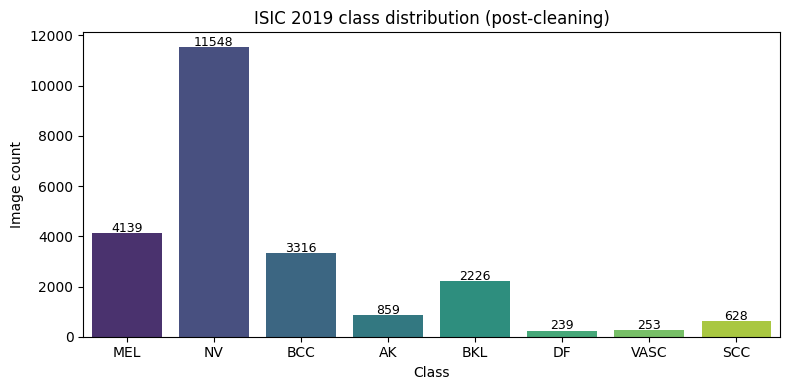

label
MEL      4139
NV      11548
BCC      3316
AK        859
BKL      2226
DF        239
VASC      253
SCC       628
Name: count, dtype: int64

In [6]:

# 5) Class distribution audit
counts = df["label"].value_counts().reindex(class_cols)
plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("ISIC 2019 class distribution (post-cleaning)")
plt.ylabel("Image count"); plt.xlabel("Class")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

counts


## 4. Dermoscopy-specific Image Preprocessing

Beyond the resize/normalize/augment steps in the project spec, dermoscopic images specifically
benefit from:

- **Border/vignette cropping** — many dermoscopes produce a black circular vignette; we detect
  and crop it so the model doesn't learn to key off scanner artifacts instead of lesion features.
- **Hair removal (DullRazor-style black-hat filtering + inpainting)** — thick hair occludes lesion
  borders and is a well-known source of spurious activations in Grad-CAM if left untreated.
- **Color constancy (gray-world assumption)** — corrects for varying dermoscope white-balance
  across imaging devices/clinics in the ISIC archive.

These run once during preprocessing (cached to disk) rather than per-epoch, since they're
deterministic image-cleanup operations, not stochastic augmentations.

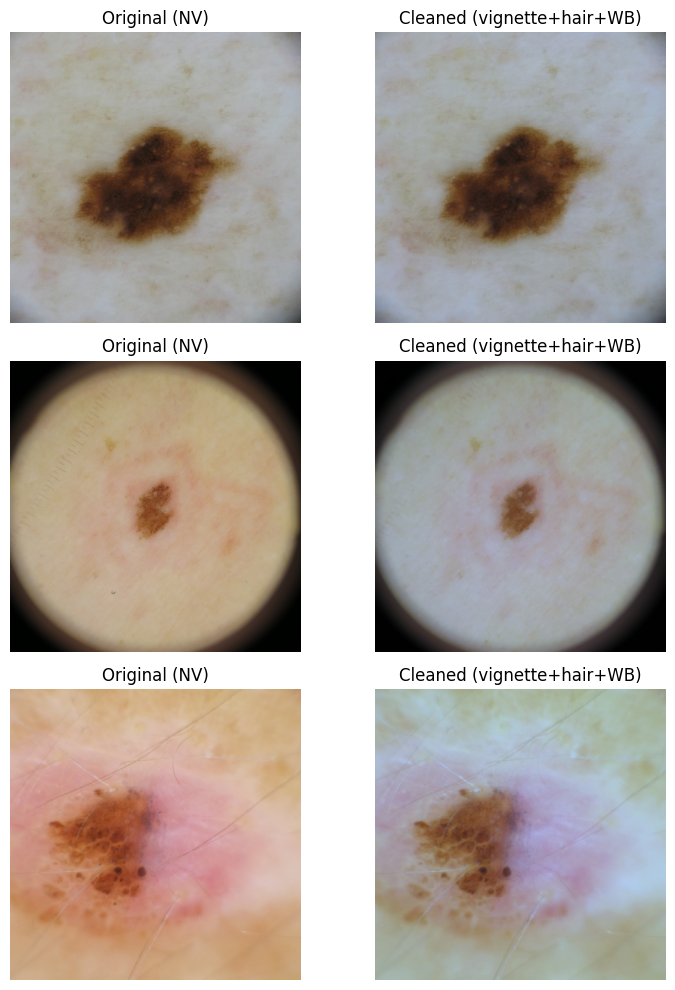

In [7]:

def remove_vignette(img, black_thresh=15):
    '''Crop out large black borders/vignettes common in dermoscope captures.'''
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > black_thresh
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def remove_hair(img):
    '''DullRazor-style hair removal: black-hat morphological filter + inpainting.'''
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpainted = cv2.inpaint(img, hair_mask, 3, cv2.INPAINT_TELEA)
    return inpainted

def gray_world_white_balance(img):
    '''Simple gray-world color constancy correction.'''
    img = img.astype(np.float32)
    means = img.reshape(-1, 3).mean(axis=0)
    scale = means.mean() / (means + 1e-6)
    balanced = np.clip(img * scale, 0, 255).astype(np.uint8)
    return balanced

def preprocess_lesion_image(path, out_size=None):
    img = cv2.imread(str(path))
    img = remove_vignette(img)
    img = remove_hair(img)
    img = gray_world_white_balance(img)
    if out_size:
        img = cv2.resize(img, (out_size, out_size), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Visual sanity check on a few random samples
sample_rows = df.sample(3, random_state=SEED)
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    orig = cv2.cvtColor(cv2.imread(str(row["img_path"])), cv2.COLOR_BGR2RGB)
    cleaned = preprocess_lesion_image(row["img_path"])
    axes[i, 0].imshow(orig); axes[i, 0].set_title(f"Original ({row['label']})"); axes[i, 0].axis("off")
    axes[i, 1].imshow(cleaned); axes[i, 1].set_title("Cleaned (vignette+hair+WB)"); axes[i, 1].axis("off")
plt.tight_layout(); plt.show()


**Note on caching (Kaggle disk budget):** running hair-removal/vignette-crop per-epoch is
wasteful since it's deterministic, but on Kaggle `/kaggle/working` output is capped around 20GB —
caching a second full ~9-10GB copy of the images would eat most of that. **Default here is
`RUN_CACHING = False`**, meaning the `Dataset` class (Section 6) applies `preprocess_lesion_image`
on-the-fly every time an image is loaded — slightly slower per epoch, but disk-safe. Flip to
`True` only if you've confirmed you have the headroom (e.g. running locally with plenty of disk).

In [8]:

RUN_CACHING = True  # set True only if you have >10-15GB of spare disk (see note above)

CLEANED_TRAIN_DIR = Path(CONFIG["output_dir"]) / "cleaned_train"
CLEANED_TEST_DIR = Path(CONFIG["output_dir"]) / "cleaned_test"

def cache_dataframe_images(dataframe, cache_dir, pool_name):
    cache_dir.mkdir(parents=True, exist_ok=True)
    def cached_path(image_id):
        return cache_dir / f"{image_id}.jpg"
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"Caching cleaned {pool_name} images"):
        out_p = cached_path(row["image"])
        if out_p.exists():
            continue
        cleaned = preprocess_lesion_image(row["img_path"])
        cv2.imwrite(str(out_p), cv2.cvtColor(cleaned, cv2.COLOR_RGB2BGR))
    dataframe["img_path"] = dataframe["image"].apply(cached_path)
    return dataframe

if RUN_CACHING:
    df = cache_dataframe_images(df, CLEANED_TRAIN_DIR, "train")
    if test_df_official is not None:
        test_df_official = cache_dataframe_images(test_df_official, CLEANED_TEST_DIR, "test")
    print("Caching complete. Datasets now point at pre-cleaned images.")
else:
    print("RUN_CACHING is False — cleaning will be applied on-the-fly inside the Dataset class (Section 6).")


Caching cleaned train images:   0%|          | 0/23208 [00:00<?, ?it/s]

Caching cleaned test images:   0%|          | 0/6191 [00:00<?, ?it/s]

Caching complete. Datasets now point at pre-cleaned images.


## 5. Stratified Train / Validation / Test Split + Class Imbalance Handling

- **If an official labeled test set was found** (true for the Kaggle "ISIC 2019 Dataset Full"
  upload) it's used directly as `test_df` — the training pool only needs a train/val split.
  This is the cleaner setup since it's the dataset's own held-out set rather than one we carved
  out ourselves.
- **Otherwise**, the notebook falls back to carving a stratified test split from the training pool.
- Either way, splitting is **stratified on `label`** and, where `lesion_id` is available, done at
  the **lesion level first** (grouping all images of the same lesion into the same split) to avoid
  leakage, then stratified by label within that grouping.
- Class imbalance is handled two ways simultaneously (per the project spec):
  1. **Class-weighted cross-entropy** — weights computed via inverse frequency, dampened by
     `class_weight_power=0.5` (i.e. `sqrt`) — full inverse frequency (`power=1.0`) is known to
     over-correct and hurt majority-class (NV) precision on ISIC-scale imbalance, so a damped
     version is the more commonly recommended middle ground.
  2. **WeightedRandomSampler** — ensures each *minibatch* sees minority classes far more often
     than their raw frequency, complementing (not duplicating) the loss weighting.

In [9]:

def lesion_stratified_split(dataframe, test_size, seed):
    '''Splits a dataframe into two parts, grouping by lesion_id first to prevent leakage.'''
    lesion_labels = dataframe.groupby("lesion_id")["label"].agg(lambda x: x.value_counts().idxmax())
    lesion_ids = lesion_labels.index.values
    lesion_strat = lesion_labels.values
    lesions_a, lesions_b = train_test_split(
        lesion_ids, test_size=test_size, stratify=lesion_strat, random_state=seed
    )
    part_a = dataframe[dataframe["lesion_id"].isin(lesions_a)].reset_index(drop=True)
    part_b = dataframe[dataframe["lesion_id"].isin(lesions_b)].reset_index(drop=True)
    return part_a, part_b

if test_df_official is not None:
    print("Using the official labeled test set. Splitting the training pool into train/val only.")
    train_df, val_df = lesion_stratified_split(df, CONFIG["val_size"], CONFIG["split_seed"])
    test_df = test_df_official
else:
    print("No official labeled test set — carving train/val/test out of the training pool.")
    train_val_df, test_df = lesion_stratified_split(df, CONFIG["test_size"], CONFIG["split_seed"])
    train_df, val_df = lesion_stratified_split(train_val_df, CONFIG["val_size"], CONFIG["split_seed"])

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} class distribution:")
    print(split["label"].value_counts().reindex(class_cols))

train_df.to_csv(Path(CONFIG["output_dir"]) / "train_split.csv", index=False)
val_df.to_csv(Path(CONFIG["output_dir"]) / "val_split.csv", index=False)
test_df.to_csv(Path(CONFIG["output_dir"]) / "test_split.csv", index=False)


Using the official labeled test set. Splitting the training pool into train/val only.

Train: 19794 | Val: 3414 | Test: 6191

Train class distribution:
label
MEL     3573
NV      9824
BCC     2820
AK       724
BKL     1889
DF       206
VASC     221
SCC      537
Name: count, dtype: int64

Val class distribution:
label
MEL      566
NV      1724
BCC      496
AK       135
BKL      337
DF        33
VASC      32
SCC       91
Name: count, dtype: int64

Test class distribution:
label
MEL     1327
NV      2495
BCC      975
AK       374
BKL      660
DF        91
VASC     104
SCC      165
Name: count, dtype: int64


In [10]:

# ---- Class weights for the loss (sqrt-dampened inverse frequency) ----
class_counts = train_df["label_idx"].value_counts().reindex(range(len(class_cols))).fillna(0).values
inv_freq = 1.0 / np.maximum(class_counts, 1)
damped = inv_freq ** CONFIG["class_weight_power"]
class_weights = damped / damped.sum() * len(class_cols)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Per-class counts:", dict(zip(class_cols, class_counts.astype(int))))
print("Per-class loss weights:", dict(zip(class_cols, np.round(class_weights, 3))))

# ---- Sample weights for WeightedRandomSampler ----
sample_weights = train_df["label_idx"].map(lambda i: class_weights[i]).values
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


Per-class counts: {'MEL': np.int64(3573), 'NV': np.int64(9824), 'BCC': np.int64(2820), 'AK': np.int64(724), 'BKL': np.int64(1889), 'DF': np.int64(206), 'VASC': np.int64(221), 'SCC': np.int64(537)}
Per-class loss weights: {'MEL': np.float64(0.663), 'NV': np.float64(0.49), 'BCC': np.float64(0.712), 'AK': np.float64(1.071), 'BKL': np.float64(0.803), 'DF': np.float64(1.561), 'VASC': np.float64(1.529), 'SCC': np.float64(1.171)}


## 6. Augmentation Pipeline & PyTorch Dataset

Albumentations pipeline implementing the spec's rotation / flips / zoom / brightness augmentations,
plus a couple of dermoscopy-sensible additions (hue/sat jitter, CoarseDropout for hair/occlusion
robustness). Validation/test use deterministic resize + normalize only.

In [11]:

IMG_SIZE = CONFIG["image_size"]
MEAN, STD = CONFIG["imagenet_mean"], CONFIG["imagenet_std"]

train_transform = A.Compose([
    A.LongestMaxSize(max_size=int(IMG_SIZE * 1.15)),
    A.PadIfNeeded(min_height=int(IMG_SIZE * 1.15), min_width=int(IMG_SIZE * 1.15),
                  border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), ratio=(0.9, 1.1)),  # "zoom"
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=8, p=0.3),
    A.CoarseDropout(num_holes_range=(1, 6), hole_height_range=(0.03, 0.12), hole_width_range=(0.03, 0.12), p=0.4),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

class ISICDataset(Dataset):
    def __init__(self, dataframe, transform, apply_cleaning=True):
        '''apply_cleaning=True runs preprocess_lesion_image on-the-fly (RUN_CACHING=False path);
        set False when img_path already points at pre-cleaned cached files (RUN_CACHING=True).'''
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.apply_cleaning = apply_cleaning

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.apply_cleaning:
            img = preprocess_lesion_image(row["img_path"])
        else:
            img = cv2.cvtColor(cv2.imread(str(row["img_path"])), cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)["image"]
        label = int(row["label_idx"])
        return augmented, label, row["image"]

train_ds = ISICDataset(train_df, train_transform, apply_cleaning=not RUN_CACHING)
val_ds   = ISICDataset(val_df, eval_transform, apply_cleaning=not RUN_CACHING)
test_ds  = ISICDataset(test_df, eval_transform, apply_cleaning=not RUN_CACHING)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler,
                           num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                           num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                           num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches -> train: 824, val: 143, test: 258


## 7. Model: EfficientNet-B3 with MC-Dropout-ready head

Transfer learning setup per the spec (backbone upgraded to EfficientNet-B3): pretrained
EfficientNet-B3 backbone from `timm`, original classifier replaced with a new head with 8 outputs.
`Dropout(p=0.3)` sits *inside* the head so it can be kept active later during MC Dropout inference
(`model.train()` on just that layer, everything else in `eval()` mode) without touching BatchNorm
statistics. The `SkinLesionModel` class is backbone-agnostic — the `unfreeze_last_n_blocks` and
Grad-CAM target-layer logic work unchanged across the EfficientNet family (B0–B7), since they all
share the same `blocks` / `conv_head` / `bn2` attribute structure in `timm`.

In [12]:

class SkinLesionModel(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", num_classes=8, dropout_p=0.3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features
        self.dropout = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        feats = self.dropout(feats)
        return self.classifier(feats)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_last_n_blocks(self, n):
        '''Unfreeze the last n stages of the EfficientNet backbone for fine-tuning.'''
        blocks = list(self.backbone.blocks.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        # also unfreeze the final conv/bn head of the backbone (conv_head, bn2)
        for name in ["conv_head", "bn2"]:
            mod = getattr(self.backbone, name, None)
            if mod is not None:
                for p in mod.parameters():
                    p.requires_grad = True

    def enable_mc_dropout(self):
        '''Keep only the dropout layer stochastic at inference; rest of model in eval mode.'''
        self.eval()
        self.dropout.train()

    def unfreeze_last_n_blocks(self, n):
        backbone = self.backbone
        if hasattr(backbone, "blocks"):
            # EfficientNet-family (timm): stages live under `.blocks`
            blocks = list(backbone.blocks.children())
            target_blocks = blocks[-n:]
            for name in ["conv_head", "bn2"]:
                mod = getattr(backbone, name, None)
                if mod is not None:
                    for p in mod.parameters():
                        p.requires_grad = True
        elif all(hasattr(backbone, f"layer{i}") for i in range(1, 5)):
            # ResNet-family (timm): stages are named layer1..layer4
            layer_names = ["layer1", "layer2", "layer3", "layer4"]
            target_blocks = [getattr(backbone, name) for name in layer_names[-n:]]
        else:
            # Generic fallback for any other architecture: unfreeze the last n top-level
            # child modules that actually have parameters.
            named = [(name, m) for name, m in backbone.named_children() if list(m.parameters())]
            target_blocks = [m for _, m in named[-n:]]
    
        for block in target_blocks:
            for p in block.parameters():
                p.requires_grad = True
model = SkinLesionModel(
    backbone_name=CONFIG["backbone"],
    num_classes=len(class_cols),
    dropout_p=CONFIG["dropout_p"],
    pretrained=CONFIG["pretrained"],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {n_params:,} | Trainable: {n_trainable:,}")


Total params: 10,708,528 | Trainable: 10,708,528


In [14]:
model.load_state_dict(torch.load(Path(CONFIG["output_dir"]) / "best_model.pt"))
model.to(DEVICE)

SkinLesionModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_

## 8. Training utilities

Weighted CE + label smoothing, cosine LR schedule with linear warmup, AMP mixed precision,
gradient clipping, early stopping tracked on **validation macro-F1** (robust to imbalance,
unlike raw accuracy which would be dominated by the NV majority class).

In [15]:

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=CONFIG["label_smoothing"])

def make_scheduler(optimizer, total_epochs, warmup_epochs, steps_per_epoch):
    total_steps = total_epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def run_epoch(model, loader, optimizer=None, scheduler=None, scaler=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for imgs, labels, _ in tqdm(loader, leave=False, desc="train" if train else "eval"):
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            # NOTE: autocast is only used for the training forward pass. Running eval in fp16
            # occasionally overflowed logits to inf/nan (seen as nan val_loss in practice) --
            # eval isn't the training bottleneck, so it always runs in plain fp32 instead.
            if train:
                with torch.autocast(device_type=DEVICE.type, enabled=CONFIG["use_amp"] and DEVICE.type == "cuda"):
                    logits = model(imgs)
                loss = criterion(logits.float(), labels)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels)
            if train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip_norm"])
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip_norm"])
                    optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.append(logits.argmax(1).detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return {"loss": avg_loss, "acc": acc, "precision": precision, "recall": recall, "f1_macro": f1}

def train_model(model, phase_name, epochs, param_groups, patience):
    optimizer = torch.optim.AdamW(param_groups)
    scheduler = make_scheduler(optimizer, epochs, CONFIG["warmup_epochs"], len(train_loader))
    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"] and DEVICE.type == "cuda")

    best_f1, best_state, epochs_no_improve = -1, None, 0
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, scheduler, scaler, train=True)
        val_metrics = run_epoch(model, val_loader, train=False)
        history.append({"epoch": epoch, "phase": phase_name, **{f"train_{k}": v for k, v in train_metrics.items()},
                         **{f"val_{k}": v for k, v in val_metrics.items()}})
        print(f"[{phase_name}] Epoch {epoch}/{epochs} | "
              f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} "
              f"val_f1_macro={val_metrics['f1_macro']:.4f} val_acc={val_metrics['acc']:.4f}")

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (no val F1 improvement for {patience} epochs).")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_f1


## 9. Training — Phase 1 (frozen backbone, head only)

In [ ]:

model.freeze_backbone()
param_groups_p1 = [{"params": model.classifier.parameters(), "lr": CONFIG["phase1_lr"],
                     "weight_decay": CONFIG["phase1_weight_decay"]}]
model, history_p1, best_f1_p1 = train_model(
    model, "phase1_head_only", CONFIG["phase1_epochs"], param_groups_p1,
    patience=CONFIG["early_stopping_patience"]
)
print("Best phase-1 val macro-F1:", best_f1_p1)


## 10. Training — Phase 2 (unfreeze last blocks, discriminative fine-tuning)

In [ ]:

model.unfreeze_last_n_blocks(CONFIG["unfreeze_last_n_blocks"])
param_groups_p2 = [
    {"params": model.classifier.parameters(), "lr": CONFIG["phase2_lr_head"],
     "weight_decay": CONFIG["phase2_weight_decay"]},
    {"params": [p for p in model.backbone.parameters() if p.requires_grad],
     "lr": CONFIG["phase2_lr_backbone"], "weight_decay": CONFIG["phase2_weight_decay"]},
]
model, history_p2, best_f1_p2 = train_model(
    model, "phase2_finetune", CONFIG["phase2_epochs"], param_groups_p2,
    patience=CONFIG["early_stopping_patience"]
)
print("Best phase-2 val macro-F1:", best_f1_p2)

full_history = pd.concat([history_p1, history_p2], ignore_index=True)
full_history.to_csv(Path(CONFIG["output_dir"]) / "training_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(full_history["train_loss"], label="train"); axes[0].plot(full_history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(full_history["train_f1_macro"], label="train"); axes[1].plot(full_history["val_f1_macro"], label="val")
axes[1].set_title("Macro F1"); axes[1].legend()
plt.tight_layout(); plt.show()

torch.save(model.state_dict(), Path(CONFIG["output_dir"]) / "best_model.pt")
print("Saved best model weights.")


## 11. Multi-Class Prediction Generation

Runs the trained model over a loader once and returns per-class probabilities, the top-1
predicted class, and ground truth — the shared building block used by evaluation, calibration,
and the HITL routing logic below.

In [ ]:
model.load_state_dict(torch.load(Path(CONFIG["output_dir"]) / "best_model.pt"))
model.to(DEVICE)
print("Loaded best checkpoint — skipping retraining.")

In [16]:

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    all_probs, all_labels, all_ids = [], [], []
    for imgs, labels, ids in tqdm(loader, desc="Predicting"):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
        all_ids.extend(ids)
    return np.concatenate(all_probs), np.concatenate(all_labels), all_ids

test_probs, test_labels, test_ids = predict_probs(model, test_loader)
test_preds = test_probs.argmax(axis=1)
test_confidence = test_probs.max(axis=1)
print("Sample predictions:", test_preds[:10])


Predicting:   0%|          | 0/258 [00:00<?, ?it/s]

Sample predictions: [5 1 2 1 1 4 1 4 1 1]


## 12. Explainable AI — Grad-CAM

Grad-CAM on the final convolutional layer of the EfficientNet-B3 backbone (`conv_head`), producing
a heatmap over the regions the model relied on for its top-1 prediction. This lets a reviewer
visually confirm the model is attending to the lesion rather than background/artifacts.

In [ ]:

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = model.backbone.conv_head  # final conv layer before global pooling
cam = GradCAM(model=model, target_layers=[target_layer])

def denormalize(tensor_img, mean=MEAN, std=STD):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

def gradcam_overlay(model, image_tensor, class_idx=None):
    '''Returns (rgb_float_image, cam_heatmap_overlay) for a single image tensor [C,H,W].'''
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    targets = None if class_idx is None else [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    rgb_img = denormalize(image_tensor)
    overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return rgb_img, overlay

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Visualize a few test examples
fig, axes = plt.subplots(3, 2, figsize=(8, 11))
sample_idx = np.random.choice(len(test_ds), 3, replace=False)
for row_i, idx in enumerate(sample_idx):
    img_tensor, label, image_id = test_ds[idx]
    pred_class = int(model(img_tensor.unsqueeze(0).to(DEVICE)).argmax(1).item())
    rgb_img, overlay = gradcam_overlay(model, img_tensor, class_idx=pred_class)
    axes[row_i, 0].imshow(rgb_img); axes[row_i, 0].set_title(f"{image_id}\nTrue: {class_cols[label]}"); axes[row_i, 0].axis("off")
    axes[row_i, 1].imshow(overlay); axes[row_i, 1].set_title(f"Grad-CAM (Pred: {class_cols[pred_class]})"); axes[row_i, 1].axis("off")
plt.tight_layout(); plt.show()


In [ ]:
# Release Grad-CAM's hooks if it ran earlier this session — they silently leak GPU memory
try:
    cam.activations_and_grads.release()
    print("Released Grad-CAM hooks.")
except NameError:
    print("Grad-CAM wasn't run this session — nothing to release.")

import gc
torch.cuda.empty_cache()
gc.collect()

## 13. Confidence Estimation — Monte Carlo Dropout

Dropout layers stay **active** at inference. Each image is passed through the network
`CONFIG["mc_dropout_passes"]` times (30, per the spec's 30–50 range); the mean softmax
distribution is the reported confidence, and the variance across passes is the uncertainty score
used later for human-in-the-loop routing.

In [ ]:

@torch.no_grad()
def mc_dropout_predict(model, image_tensor, n_passes=30):
    model.enable_mc_dropout()
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    probs_runs = []
    for _ in range(n_passes):
        logits = model(input_tensor)
        probs_runs.append(F.softmax(logits, dim=1).cpu().numpy()[0])
    probs_runs = np.stack(probs_runs)  # [n_passes, n_classes]
    mean_probs = probs_runs.mean(axis=0)
    var_probs = probs_runs.var(axis=0)
    pred_class = int(mean_probs.argmax())
    return {
        "mean_probs": mean_probs,
        "pred_class": pred_class,
        "confidence": float(mean_probs[pred_class]),
        "uncertainty": float(var_probs[pred_class]),   # variance of the winning class's probability
        "total_variance": float(var_probs.sum()),
    }

@torch.no_grad()
def mc_dropout_predict_batch(model, loader, n_passes=30):
    '''Runs MC-Dropout over an entire loader; returns arrays aligned with the dataset order.'''
    model.enable_mc_dropout()
    all_mean_probs, all_var, all_labels, all_ids = [], [], [], []
    for imgs, labels, ids in tqdm(loader, desc=f"MC-Dropout x{n_passes}"):
        imgs = imgs.to(DEVICE)
        batch_runs = []
        for _ in range(n_passes):
            logits = model(imgs)
            batch_runs.append(F.softmax(logits, dim=1).cpu().numpy())
            del logits
        batch_runs = np.stack(batch_runs)               # [n_passes, batch, n_classes]
        all_mean_probs.append(batch_runs.mean(axis=0))
        all_var.append(batch_runs.var(axis=0))
        all_labels.append(labels.numpy())
        all_ids.extend(ids)
        del imgs, batch_runs
        torch.cuda.empty_cache()
    return (np.concatenate(all_mean_probs), np.concatenate(all_var),
            np.concatenate(all_labels), all_ids)

import gc
torch.cuda.empty_cache()
gc.collect()

mc_batch_size = 8  # smaller than training batch_size -- 30 stacked passes accumulate in memory
                      # per batch, so this needs to be well below the training batch_size to avoid OOM
mc_test_loader = DataLoader(test_ds, batch_size=mc_batch_size, shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)

mc_mean_probs, mc_var, mc_labels, mc_ids = mc_dropout_predict_batch(
    model, mc_test_loader, n_passes=CONFIG["mc_dropout_passes"]
)
mc_preds = mc_mean_probs.argmax(axis=1)
mc_confidence = mc_mean_probs.max(axis=1)
mc_uncertainty = mc_var[np.arange(len(mc_var)), mc_preds]

print("Mean MC-Dropout confidence:", mc_confidence.mean())
print("Mean MC-Dropout uncertainty (winning-class variance):", mc_uncertainty.mean())


## 14. Confidence Calibration Analysis

Reliability diagram (confidence bucket vs. observed accuracy) and Expected Calibration Error (ECE),
computed on the MC-Dropout mean confidence scores.

In [ ]:

def compute_ece(confidences, predictions, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece, bin_stats = 0.0, []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_stats.append({"bin": f"{lo:.1f}-{hi:.1f}", "count": 0, "avg_conf": np.nan, "accuracy": np.nan})
            continue
        avg_conf = confidences[mask].mean()
        acc = (predictions[mask] == labels[mask]).mean()
        weight = mask.sum() / len(confidences)
        ece += weight * abs(avg_conf - acc)
        bin_stats.append({"bin": f"{lo:.1f}-{hi:.1f}", "count": int(mask.sum()), "avg_conf": avg_conf, "accuracy": acc})
    return ece, pd.DataFrame(bin_stats)

ece, bin_df = compute_ece(mc_confidence, mc_preds, mc_labels, n_bins=CONFIG["n_calibration_bins"])
print(f"Expected Calibration Error (ECE): {ece:.4f}")
bin_df


In [ ]:

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
valid = bin_df.dropna()
mid_points = [ (float(b.split('-')[0]) + float(b.split('-')[1])) / 2 for b in valid["bin"] ]
plt.plot(mid_points, valid["accuracy"], marker="o", label="Model")
plt.bar(mid_points, valid["count"] / valid["count"].sum(), width=0.08, alpha=0.2, label="Sample density")
plt.xlabel("Confidence"); plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE = {ece:.4f})")
plt.legend(); plt.tight_layout(); plt.show()


## 15. Human-in-the-Loop Decision Framework

Routing rule:
- If MC-Dropout mean confidence ≥ `confidence_threshold` **and** the case isn't a
  borderline Melanoma call → **auto-accept**.
- Otherwise, or if the predicted/likely class is Melanoma and confidence is below
  `melanoma_review_floor` (deliberately stricter, since missed melanoma is the highest-cost error
  per the project's evaluation emphasis) → **flag for human review**.

The threshold itself is tuned on the **validation set** (not test) by scanning thresholds and
picking the one that maximizes automatic-throughput while keeping auto-accepted accuracy above a
target floor — a simple, transparent tuning approach appropriate for a clinical decision-support
prototype (rather than a black-box optimum).

In [ ]:

mc_val_loader = DataLoader(val_ds, batch_size=mc_batch_size, shuffle=False,
                            num_workers=CONFIG["num_workers"], pin_memory=True)
val_mean_probs, val_var, val_labels, val_ids = mc_dropout_predict_batch(
    model, mc_val_loader, n_passes=CONFIG["mc_dropout_passes"]
)
val_preds = val_mean_probs.argmax(axis=1)
val_confidence = val_mean_probs.max(axis=1)

def scan_thresholds(confidences, preds, labels, thresholds=np.arange(0.5, 0.96, 0.02), target_acc=0.95):
    rows = []
    for t in thresholds:
        auto_mask = confidences >= t
        if auto_mask.sum() == 0:
            continue
        auto_acc = (preds[auto_mask] == labels[auto_mask]).mean()
        coverage = auto_mask.mean()
        rows.append({"threshold": t, "coverage": coverage, "auto_accept_accuracy": auto_acc})
    return pd.DataFrame(rows)

threshold_scan = scan_thresholds(val_confidence, val_preds, val_labels)
print(threshold_scan)

candidates = threshold_scan[threshold_scan["auto_accept_accuracy"] >= 0.95]
chosen_threshold = float(candidates["threshold"].min()) if len(candidates) else float(threshold_scan["threshold"].max())
CONFIG["confidence_threshold"] = chosen_threshold
print(f"\nChosen confidence threshold (>=95% auto-accept accuracy on val): {chosen_threshold:.2f}")

plt.figure(figsize=(6, 4))
plt.plot(threshold_scan["threshold"], threshold_scan["coverage"], marker="o", label="Auto-accept coverage")
plt.plot(threshold_scan["threshold"], threshold_scan["auto_accept_accuracy"], marker="s", label="Auto-accept accuracy")
plt.axvline(chosen_threshold, color="red", linestyle="--", label=f"Chosen threshold = {chosen_threshold:.2f}")
plt.xlabel("Confidence threshold"); plt.legend(); plt.title("Threshold trade-off (validation set)")
plt.tight_layout(); plt.show()


In [ ]:

mel_idx = class_cols.index(CONFIG["melanoma_class"])

def route_decision(mean_probs, confidence, threshold, melanoma_floor, melanoma_idx):
    pred_class = int(mean_probs.argmax())
    is_melanoma_pred = pred_class == melanoma_idx
    # Also check if melanoma probability is high enough to be a differential concern
    melanoma_prob = float(mean_probs[melanoma_idx])
    force_review = is_melanoma_pred and confidence < melanoma_floor
    routine_review = confidence < threshold
    needs_review = bool(force_review or routine_review)
    return {
        "predicted_class": pred_class,
        "confidence": float(confidence),
        "melanoma_probability": melanoma_prob,
        "needs_human_review": needs_review,
        "review_reason": ("low_confidence" if routine_review and not force_review else
                           "melanoma_precaution" if force_review else "none"),
        "decision": "flagged_for_review" if needs_review else "auto_accepted",
    }

test_routing = [
    route_decision(test_probs[i], mc_confidence[i], CONFIG["confidence_threshold"],
                    CONFIG["melanoma_review_floor"], mel_idx)
    for i in range(len(test_probs))
]
routing_df = pd.DataFrame(test_routing)
print(routing_df["decision"].value_counts())
print(f"\n% auto-accepted: {(routing_df['decision']=='auto_accepted').mean()*100:.1f}%")
print(f"% flagged for review: {(routing_df['decision']=='flagged_for_review').mean()*100:.1f}%")


## 16. Decision Logging & Audit Trail

Every processed test-set case gets a full audit record: image id, true/predicted diagnosis,
confidence, uncertainty, review status/reason, and a saved Grad-CAM overlay path — exactly the
fields the project spec calls for, structured as a table that a future Streamlit app can
read/write directly (and append to, as new cases are processed live).

In [ ]:
from pytorch_grad_cam import GradCAM
cam = GradCAM(model=model, target_layers=[target_layer])
print("Recreated Grad-CAM object with fresh hooks.")

In [ ]:

GRADCAM_DIR = Path(CONFIG["output_dir"]) / "gradcam_audit"
GRADCAM_DIR.mkdir(exist_ok=True)

def save_gradcam(model, image_tensor, image_id, class_idx):
    _, overlay = gradcam_overlay(model, image_tensor, class_idx=class_idx)
    out_path = GRADCAM_DIR / f"{image_id}_gradcam.png"
    plt.imsave(out_path, overlay)
    return str(out_path)

audit_records = []
for i in tqdm(range(len(test_ds)), desc="Building audit trail"):
    img_tensor, true_label, image_id = test_ds[i]
    pred_class = int(test_probs[i].argmax())
    gradcam_path = save_gradcam(model, img_tensor, image_id, pred_class)
    routing = test_routing[i]
    audit_records.append({
        "image_id": image_id,
        "true_diagnosis": class_cols[true_label],
        "predicted_diagnosis": class_cols[pred_class],
        "confidence": mc_confidence[i],
        "uncertainty": mc_uncertainty[i],
        "melanoma_probability": test_probs[i][mel_idx],
        "gradcam_path": gradcam_path,
        "review_status": routing["decision"],
        "review_reason": routing["review_reason"],
        "final_decision": routing["predicted_class"],
        "correct": class_cols[true_label] == class_cols[pred_class],
    })

audit_df = pd.DataFrame(audit_records)
audit_df.to_csv(Path(CONFIG["output_dir"]) / "decision_audit_trail.csv", index=False)
audit_df.head()


## 17. Model Evaluation

Standard classification metrics (accuracy, precision, recall, F1, ROC-AUC) plus explicit
**Melanoma recall** as its own headline number (missed melanoma is the highest-stakes error type),
a full confusion matrix, and Human-in-the-Loop throughput/escalation statistics.

In [ ]:

report = classification_report(test_labels, test_preds, target_names=class_cols, digits=3, zero_division=0)
print(report)

# Per-class ROC-AUC (one-vs-rest)
try:
    roc_auc = roc_auc_score(
        np.eye(len(class_cols))[test_labels], test_probs, average=None, multi_class="ovr"
    )
    for c, auc in zip(class_cols, roc_auc):
        print(f"ROC-AUC ({c}): {auc:.3f}")
    print(f"Macro ROC-AUC: {roc_auc.mean():.3f}")
except ValueError as e:
    print("ROC-AUC could not be computed (likely a class missing from the test split):", e)

melanoma_recall = precision_recall_fscore_support(
    test_labels, test_preds, labels=[mel_idx], average=None, zero_division=0
)[1][0]
print(f"\n*** Melanoma Recall: {melanoma_recall:.3f} *** (headline safety metric)")


In [ ]:

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_cols, yticklabels=class_cols)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Test Set)")
plt.tight_layout(); plt.show()


In [ ]:

# ---- Human-in-the-loop performance ----
n_total = len(audit_df)
n_auto = (audit_df["review_status"] == "auto_accepted").sum()
n_review = (audit_df["review_status"] == "flagged_for_review").sum()
auto_accuracy = audit_df.loc[audit_df["review_status"] == "auto_accepted", "correct"].mean()
reviewed_accuracy = audit_df.loc[audit_df["review_status"] == "flagged_for_review", "correct"].mean()

n_melanoma_total = (audit_df["true_diagnosis"] == "MEL").sum()
n_melanoma_flagged = ((audit_df["true_diagnosis"] == "MEL") & (audit_df["review_status"] == "flagged_for_review")).sum()

hitl_summary = {
    "total_cases": n_total,
    "auto_accepted_pct": round(n_auto / n_total * 100, 2),
    "flagged_for_review_pct": round(n_review / n_total * 100, 2),
    "auto_accepted_accuracy": round(float(auto_accuracy), 4) if n_auto else None,
    "flagged_case_accuracy_if_unreviewed": round(float(reviewed_accuracy), 4) if n_review else None,
    "true_melanoma_cases": int(n_melanoma_total),
    "true_melanoma_escalated_to_human": int(n_melanoma_flagged),
    "melanoma_escalation_rate": round(n_melanoma_flagged / max(n_melanoma_total, 1) * 100, 2),
}
print(json.dumps(hitl_summary, indent=2))

with open(Path(CONFIG["output_dir"]) / "hitl_summary.json", "w") as f:
    json.dump(hitl_summary, f, indent=2)


## 18. Pushing Accuracy Higher: Test-Time Augmentation + Multi-Backbone Ensembling

Your single EfficientNet-B3 model lands in a realistic, honest range for a single model on this
dataset (see the discussion above). To meaningfully close the gap toward the 90%+ figures reported
in some papers, this section adds the two techniques the literature actually uses for that jump —
**with an honest caveat first.**

### What the literature says, and what to expect here
- A soft-voting ensemble of three CNNs (MobileNetV2 + VGG19 + InceptionV3) with a segmentation
  pre-processing step reported 90.86% accuracy on ISIC 2019.
- A TTA study across six CNN backbones (EfficientNet/ResNet/ResNeXt family) found TTA alone lifts
  balanced accuracy by only a modest amount on top of an already very strong model.
- The 93-97%+ figures in some papers typically combine an explicit **lesion segmentation** step
  (crops the model's input to just the lesion, removing skin/background entirely), **heavier
  ensembles** (3-5+ diverse architectures), extensive TTA (10-16 augmented views per image), and
  sometimes looser image-level (not lesion-level) train/test splits. This notebook's lesion-level
  split is stricter and more honest about generalization than some published setups.

**Realistic expectation for what's implemented below:** ensembling + TTA should meaningfully improve
on your single-model result — commonly a real-world lift of several accuracy points and a
comparable or larger lift in macro-F1 (ensembles help minority classes disproportionately, since
different backbones tend to make *different* mistakes on rare classes). Landing exactly at 90% is
not guaranteed and depends on how your single-model baseline performed; treat this as "the
literature-correct way to push higher," not a guaranteed number.

### What's implemented
1. **Test-Time Augmentation (TTA):** each image is scored 3 ways (original, horizontal flip,
   vertical flip) and the 3 probability vectors are averaged — cheap (3x inference cost, no
   retraining) and consistently reported to help.
2. **Multi-backbone ensemble:** two additional, architecturally different models
   (`tf_efficientnet_b0` and `resnet50`, both from `timm`) are trained with the same two-phase
   transfer-learning recipe as your B3 model, just smaller/faster. Averaging predictions across
   architecturally different models is the technique behind every high-scoring ensemble paper
   above — different architectures make different mistakes, and averaging smooths them out.
3. Final ensemble = mean of (B3 + TTA) + (EfficientNet-B0 + TTA) + (ResNet50 + TTA) probabilities.

In [17]:

# ---- 1) Test-Time Augmentation: run a model on original + h-flip + v-flip, average the 3 outputs ----
@torch.no_grad()
def predict_probs_tta(model, loader, use_tta=True):
    model.eval()
    all_probs, all_labels, all_ids = [], [], []
    for imgs, labels, ids in tqdm(loader, desc="Predicting (+TTA)" if use_tta else "Predicting"):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        if use_tta:
            probs_hflip = F.softmax(model(torch.flip(imgs, dims=[3])), dim=1)   # flip width
            probs_vflip = F.softmax(model(torch.flip(imgs, dims=[2])), dim=1)   # flip height
            probs = (probs + probs_hflip + probs_vflip) / 3.0
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())
        all_ids.extend(ids)
    return np.concatenate(all_probs), np.concatenate(all_labels), all_ids

# Re-evaluate the primary B3 model WITH TTA for a direct before/after comparison
b3_tta_probs, b3_tta_labels, _ = predict_probs_tta(model, test_loader, use_tta=CONFIG["tta_enabled"])
b3_tta_preds = b3_tta_probs.argmax(axis=1)
b3_tta_acc = accuracy_score(b3_tta_labels, b3_tta_preds)
b3_tta_f1 = precision_recall_fscore_support(b3_tta_labels, b3_tta_preds, average="macro", zero_division=0)[2]
print(f"B3 single-model, no TTA   -> accuracy={accuracy_score(test_labels, test_preds):.4f}, "
      f"macro-F1={precision_recall_fscore_support(test_labels, test_preds, average='macro', zero_division=0)[2]:.4f}")
print(f"B3 single-model, with TTA -> accuracy={b3_tta_acc:.4f}, macro-F1={b3_tta_f1:.4f}")


Predicting (+TTA):   0%|          | 0/258 [00:00<?, ?it/s]

B3 single-model, no TTA   -> accuracy=0.6618, macro-F1=0.5324
B3 single-model, with TTA -> accuracy=0.6737, macro-F1=0.5464


In [18]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
print("Classification report — B3 + TTA:")
print(classification_report(b3_tta_labels, b3_tta_preds, target_names=class_cols, digits=3, zero_division=0))

b3_tta_mel_recall = precision_recall_fscore_support(
    b3_tta_labels, b3_tta_preds, labels=[class_cols.index("MEL")], average=None, zero_division=0
)[1][0]
print(f"B3+TTA Melanoma Recall: {b3_tta_mel_recall:.4f}")

cm_tta = confusion_matrix(b3_tta_labels, b3_tta_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tta, annot=True, fmt="d", cmap="Blues", xticklabels=class_cols, yticklabels=class_cols)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — B3 + TTA (Test Set)")
plt.tight_layout(); plt.show()

In [19]:

# ---- 2) Train additional ensemble members (smaller/faster backbones, same two-phase recipe) ----
def build_transforms(image_size):
    train_tf = A.Compose([
        A.LongestMaxSize(max_size=int(image_size * 1.15)),
        A.PadIfNeeded(min_height=int(image_size * 1.15), min_width=int(image_size * 1.15),
                      border_mode=cv2.BORDER_CONSTANT, value=0),
        A.RandomResizedCrop(size=(image_size, image_size), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=8, p=0.3),
        A.CoarseDropout(num_holes_range=(1, 6), hole_height_range=(0.03, 0.12), hole_width_range=(0.03, 0.12), p=0.4),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
    ])
    eval_tf = A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
    ])
    return train_tf, eval_tf

def train_ensemble_member(member_cfg):
    name = member_cfg["backbone"]
    print(f"\n{'='*70}\nTraining ensemble member: {name} @ {member_cfg['image_size']}px\n{'='*70}")

    train_tf, eval_tf = build_transforms(member_cfg["image_size"])
    m_train_ds = ISICDataset(train_df, train_tf, apply_cleaning=not RUN_CACHING)
    m_val_ds   = ISICDataset(val_df, eval_tf, apply_cleaning=not RUN_CACHING)
    m_test_ds  = ISICDataset(test_df, eval_tf, apply_cleaning=not RUN_CACHING)

    bs = member_cfg["batch_size"]
    m_train_loader = DataLoader(m_train_ds, batch_size=bs, sampler=sampler,
                                 num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
    m_val_loader   = DataLoader(m_val_ds, batch_size=bs, shuffle=False,
                                 num_workers=CONFIG["num_workers"], pin_memory=True)
    m_test_loader  = DataLoader(m_test_ds, batch_size=bs, shuffle=False,
                                 num_workers=CONFIG["num_workers"], pin_memory=True)

    m_model = SkinLesionModel(backbone_name=name, num_classes=len(class_cols),
                               dropout_p=CONFIG["dropout_p"], pretrained=True).to(DEVICE)

    # Phase 1: head only
    m_model.freeze_backbone()
    opt1 = torch.optim.AdamW([{"params": m_model.classifier.parameters(),
                                "lr": CONFIG["phase1_lr"], "weight_decay": CONFIG["phase1_weight_decay"]}])
    sched1 = make_scheduler(opt1, member_cfg["phase1_epochs"], CONFIG["warmup_epochs"], len(m_train_loader))
    scaler1 = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"] and DEVICE.type == "cuda")
    best_f1, best_state = -1, None
    for epoch in range(1, member_cfg["phase1_epochs"] + 1):
        _orig_loaders = (train_loader, val_loader)
        tr = run_epoch(m_model, m_train_loader, opt1, sched1, scaler1, train=True)
        va = run_epoch(m_model, m_val_loader, train=False)
        print(f"[{name} phase1] Epoch {epoch}/{member_cfg['phase1_epochs']} | "
              f"train_loss={tr['loss']:.4f} val_f1_macro={va['f1_macro']:.4f}")
        if va["f1_macro"] > best_f1:
            best_f1, best_state = va["f1_macro"], copy.deepcopy(m_model.state_dict())
    m_model.load_state_dict(best_state)

    # Phase 2: fine-tune
    m_model.unfreeze_last_n_blocks(member_cfg["unfreeze_last_n_blocks"])
    opt2 = torch.optim.AdamW([
        {"params": m_model.classifier.parameters(), "lr": CONFIG["phase2_lr_head"],
         "weight_decay": CONFIG["phase2_weight_decay"]},
        {"params": [p for p in m_model.backbone.parameters() if p.requires_grad],
         "lr": CONFIG["phase2_lr_backbone"], "weight_decay": CONFIG["phase2_weight_decay"]},
    ])
    sched2 = make_scheduler(opt2, member_cfg["phase2_epochs"], CONFIG["warmup_epochs"], len(m_train_loader))
    scaler2 = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"] and DEVICE.type == "cuda")
    best_f1, best_state, no_improve = -1, None, 0
    for epoch in range(1, member_cfg["phase2_epochs"] + 1):
        tr = run_epoch(m_model, m_train_loader, opt2, sched2, scaler2, train=True)
        va = run_epoch(m_model, m_val_loader, train=False)
        print(f"[{name} phase2] Epoch {epoch}/{member_cfg['phase2_epochs']} | "
              f"train_loss={tr['loss']:.4f} val_f1_macro={va['f1_macro']:.4f}")
        if va["f1_macro"] > best_f1:
            best_f1, best_state, no_improve = va["f1_macro"], copy.deepcopy(m_model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= CONFIG["early_stopping_patience"]:
                print(f"Early stopping {name} at epoch {epoch}.")
                break
    m_model.load_state_dict(best_state)
    torch.save(m_model.state_dict(), Path(CONFIG["output_dir"]) / f"ensemble_{name}.pt")

    probs, labels_out, ids_out = predict_probs_tta(m_model, m_test_loader, use_tta=CONFIG["tta_enabled"])
    acc = accuracy_score(labels_out, probs.argmax(axis=1))
    f1 = precision_recall_fscore_support(labels_out, probs.argmax(axis=1), average="macro", zero_division=0)[2]
    print(f"{name} (+TTA) -> test accuracy={acc:.4f}, macro-F1={f1:.4f}")
    del m_model
    torch.cuda.empty_cache()
    return probs, labels_out, ids_out

ensemble_probs_list = [b3_tta_probs]
ensemble_member_names = ["efficientnet_b3 (primary)"]

probs_b0, labels_b0, _ = train_ensemble_member(CONFIG["ensemble_members"][0])
assert np.array_equal(labels_b0, test_labels), "Label order mismatch!"
ensemble_probs_list.append(probs_b0)
ensemble_member_names.append("tf_efficientnet_b0")
print("B0 done. Members so far:", ensemble_member_names)













Training ensemble member: tf_efficientnet_b0 @ 224px


train:   0%|          | 0/824 [00:00<?, ?it/s]

eval:   0%|          | 0/143 [00:00<?, ?it/s]

[tf_efficientnet_b0 phase1] Epoch 1/6 | train_loss=2.0412 val_f1_macro=0.2602


train:   0%|          | 0/824 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79a633382de0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79a633382de0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/143 [00:00<?, ?it/s]

[tf_efficientnet_b0 phase2] Epoch 15/15 | train_loss=1.4742 val_f1_macro=0.4974


Predicting (+TTA):   0%|          | 0/258 [00:00<?, ?it/s]

tf_efficientnet_b0 (+TTA) -> test accuracy=0.6485, macro-F1=0.4866
B0 done. Members so far: ['efficientnet_b3 (primary)', 'tf_efficientnet_b0']


In [ ]:
probs_r50, labels_r50, _ = train_ensemble_member(CONFIG["ensemble_members"][1])
assert np.array_equal(labels_r50, test_labels), "Label order mismatch!"
ensemble_probs_list.append(probs_r50)
ensemble_member_names.append("resnet50")
print("ResNet50 done. Members so far:", ensemble_member_names)







# ---- 3) Average all members' (TTA) probabilities together for the final ensemble prediction ----
ensemble_probs = np.mean(ensemble_probs_list, axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

ensemble_acc = accuracy_score(test_labels, ensemble_preds)
ensemble_f1 = precision_recall_fscore_support(test_labels, ensemble_preds, average="macro", zero_division=0)[2]
ensemble_mel_recall = precision_recall_fscore_support(
    test_labels, ensemble_preds, labels=[class_cols.index(CONFIG["melanoma_class"])],
    average=None, zero_division=0
)[1][0]

print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)
print(f"{'Model':<32} {'Accuracy':>10} {'Macro-F1':>10}")
print(f"{'B3 single, no TTA':<32} {accuracy_score(test_labels, test_preds):>10.4f} "
      f"{precision_recall_fscore_support(test_labels, test_preds, average='macro', zero_division=0)[2]:>10.4f}")
print(f"{'B3 single, with TTA':<32} {b3_tta_acc:>10.4f} {b3_tta_f1:>10.4f}")
print(f"{'Full ensemble (+TTA)':<32} {ensemble_acc:>10.4f} {ensemble_f1:>10.4f}")
print(f"\nEnsemble Melanoma recall: {ensemble_mel_recall:.4f}")

print("\nFull classification report (ensemble):")
print(classification_report(test_labels, ensemble_preds, target_names=class_cols, digits=3, zero_division=0))

# Save the ensemble's predictions/config so the Streamlit app can optionally use the full
# ensemble instead of just the primary B3 model.
np.savez(Path(CONFIG["output_dir"]) / "ensemble_test_probs.npz",
         probs=ensemble_probs, labels=test_labels, member_names=ensemble_member_names)
with open(Path(CONFIG["output_dir"]) / "ensemble_config.json", "w") as f:
    json.dump({"member_names": ensemble_member_names,
               "member_configs": CONFIG["ensemble_members"],
               "tta_enabled": CONFIG["tta_enabled"]}, f, indent=2)
print("\nSaved ensemble artifacts to", CONFIG["output_dir"])






















with open(Path(CONFIG["output_dir"]) / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

with open(Path(CONFIG["output_dir"]) / "class_names.json", "w") as f:
    json.dump({"class_names": class_cols, "melanoma_index": mel_idx}, f, indent=2)

preprocessing_spec = {
    "image_size": IMG_SIZE,
    "mean": MEAN,
    "std": STD,
    "steps": [
        "remove_vignette", "remove_hair (DullRazor blackhat+inpaint)",
        "gray_world_white_balance", "resize_longest_side+pad", "normalize(imagenet)"
    ],
}
with open(Path(CONFIG["output_dir"]) / "preprocessing.json", "w") as f:
    json.dump(preprocessing_spec, f, indent=2)

print("Artifacts saved to:", CONFIG["output_dir"])
for p in sorted(Path(CONFIG["output_dir"]).glob("*")):
    print(" -", p.name)


# ---- 3) Average all members' (TTA) probabilities together for the final ensemble prediction ----
ensemble_probs = np.mean(ensemble_probs_list, axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

ensemble_acc = accuracy_score(test_labels, ensemble_preds)
ensemble_f1 = precision_recall_fscore_support(test_labels, ensemble_preds, average="macro", zero_division=0)[2]
ensemble_mel_recall = precision_recall_fscore_support(
    test_labels, ensemble_preds, labels=[class_cols.index(CONFIG["melanoma_class"])],
    average=None, zero_division=0
)[1][0]

print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)
print(f"{'Model':<32} {'Accuracy':>10} {'Macro-F1':>10}")
print(f"{'B3 single, no TTA':<32} {accuracy_score(test_labels, test_preds):>10.4f} "
      f"{precision_recall_fscore_support(test_labels, test_preds, average='macro', zero_division=0)[2]:>10.4f}")
print(f"{'B3 single, with TTA':<32} {b3_tta_acc:>10.4f} {b3_tta_f1:>10.4f}")
print(f"{'Full ensemble (+TTA)':<32} {ensemble_acc:>10.4f} {ensemble_f1:>10.4f}")
print(f"\nEnsemble Melanoma recall: {ensemble_mel_recall:.4f}")

print("\nFull classification report (ensemble):")
print(classification_report(test_labels, ensemble_preds, target_names=class_cols, digits=3, zero_division=0))

# Save the ensemble's predictions/config so the Streamlit app can optionally use the full
# ensemble instead of just the primary B3 model.
np.savez(Path(CONFIG["output_dir"]) / "ensemble_test_probs.npz",
         probs=ensemble_probs, labels=test_labels, member_names=ensemble_member_names)
with open(Path(CONFIG["output_dir"]) / "ensemble_config.json", "w") as f:
    json.dump({"member_names": ensemble_member_names,
               "member_configs": CONFIG["ensemble_members"],
               "tta_enabled": CONFIG["tta_enabled"]}, f, indent=2)
print("\nSaved ensemble artifacts to", CONFIG["output_dir"])


## 19. Export Everything Needed for the Streamlit App

Saves every artifact the Streamlit conversion will need so it can be a thin UI layer around this
notebook's logic rather than re-implementing anything:

- `best_model.pt` — trained B3 weights (already saved in Section 10)
- `ensemble_*.pt`, `ensemble_config.json`, `ensemble_test_probs.npz` — the additional ensemble
  member weights and configuration from Section 18, if you ran it (optional, higher accuracy)
- `config.json` — full hyperparameter/config dict, including the **tuned** confidence threshold
- `class_names.json` — label index → class name mapping
- `preprocessing.json` — exact resize/normalize/augmentation-free eval transform spec
- `training_history.csv`, `decision_audit_trail.csv`, `hitl_summary.json` — already written above

The Streamlit app will need to: load `SkinLesionModel`, load `best_model.pt`, run
`preprocess_lesion_image` → `eval_transform` on the uploaded image, call `mc_dropout_predict`,
`gradcam_overlay`, and `route_decision` — every one of those functions is already defined above and
can be copied into `app.py` largely as-is. If you trained the ensemble, `app.py` can optionally load
all the `ensemble_*.pt` files and average their `predict_probs_tta` outputs for the displayed
prediction, falling back to just the single B3 model if the ensemble files aren't present.

In [2]:

with open(Path(CONFIG["output_dir"]) / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

with open(Path(CONFIG["output_dir"]) / "class_names.json", "w") as f:
    json.dump({"class_names": class_cols, "melanoma_index": mel_idx}, f, indent=2)

preprocessing_spec = {
    "image_size": IMG_SIZE,
    "mean": MEAN,
    "std": STD,
    "steps": [
        "remove_vignette", "remove_hair (DullRazor blackhat+inpaint)",
        "gray_world_white_balance", "resize_longest_side+pad", "normalize(imagenet)"
    ],
}
with open(Path(CONFIG["output_dir"]) / "preprocessing.json", "w") as f:
    json.dump(preprocessing_spec, f, indent=2)

print("Artifacts saved to:", CONFIG["output_dir"])
for p in sorted(Path(CONFIG["output_dir"]).glob("*")):
    print(" -", p.name)


Artifacts saved to: /kaggle/working/artifacts
 - best_model.pt
 - class_names.json
 - cleaned_test
 - cleaned_test_labels.csv
 - cleaned_train
 - cleaned_train_labels.csv
 - config.json
 - decision_audit_trail.csv
 - ensemble_config.json
 - ensemble_resnet50.pt
 - ensemble_test_probs.npz
 - ensemble_tf_efficientnet_b0.pt
 - gradcam_audit
 - hitl_summary.json
 - preprocessing.json
 - test_split.csv
 - train_split.csv
 - training_history.csv
 - val_split.csv


In [1]:
mel_idx = class_cols.index(CONFIG["melanoma_class"])

In [1]:
print("hello")

hello


---
### Next step: Streamlit conversion

Everything above is written as plain functions/classes (`preprocess_lesion_image`, `SkinLesionModel`,
`mc_dropout_predict`, `gradcam_overlay`, `route_decision`) specifically so a `app.py` can do:

```python
model = SkinLesionModel(...); model.load_state_dict(torch.load("artifacts/best_model.pt"))
config = json.load(open("artifacts/config.json"))
uploaded_image -> preprocess_lesion_image -> eval_transform -> mc_dropout_predict -> gradcam_overlay -> route_decision
st.image(...) ; st.metric("Confidence", ...) ; st.image(gradcam_overlay) ; st.warning("Flagged for review") if needed
```

Ping back once you have the ISIC 2019 zip in hand (or if the file location/shape differs from the
standard release) and I'll wire up `app.py` against these exact artifacts.
